# <span style = "color:CYAN"><center> Emotions in Text Prediction with LSTM </center></span>

***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('Emotion_final.csv')

In [3]:
df.head()

,Text,Emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


### Some of the texts along with its emotions

In [4]:
for i in range(10):
    print(df['Text'][i]  , '-' , df['Emotion'][i])
    print()

i didnt feel humiliated - sadness

i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake - sadness

im grabbing a minute to post i feel greedy wrong - anger

i am ever feeling nostalgic about the fireplace i will know that it is still on the property - love

i am feeling grouchy - anger

ive been feeling a little burdened lately wasnt sure why that was - sadness

ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny - surprise

i feel as confused about life as a teenager or as jaded as a year old man - fear

i have been with petronas for years i feel that petronas has performed well and made a huge profit - happy

i feel romantic too - love



In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21459 entries, 0 to 21458
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Text     21459 non-null  object
 1   Emotion  21459 non-null  object
dtypes: object(2)
memory usage: 335.4+ KB


### Basic statistical information about the dataset

In [6]:
df.describe()

,Text,Emotion
count,21459,21459
unique,21405,6
top,i feel more adventurous willing to take risks ...,happy
freq,2,7029


### Checking for null values

In [7]:
df.isna().sum()

Text       0
Emotion    0
dtype: int64

### Checking for duplicated values

In [8]:
df.duplicated().sum()

np.int64(3)

In [9]:
df.drop_duplicates(inplace= True, keep = 'first')

### Countplot of 'Emotions'

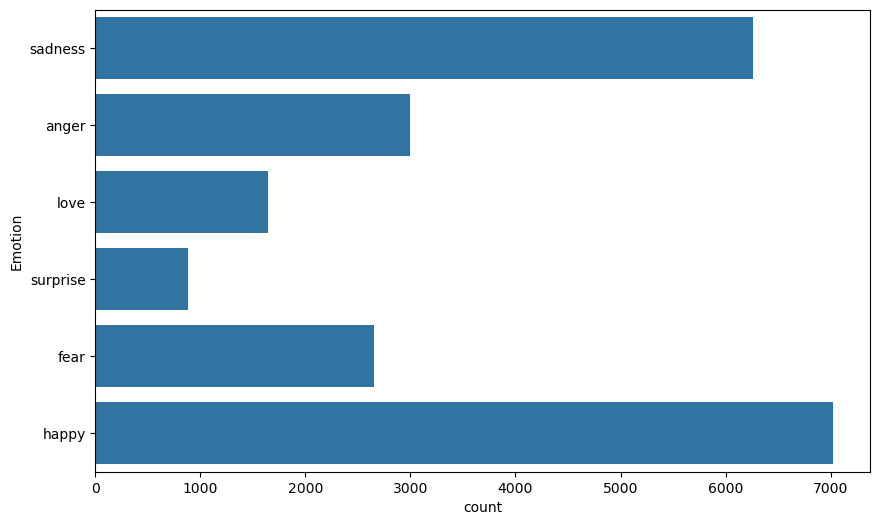

In [10]:
plt.figure(figsize = (10,6))
sns.countplot(y = df['Emotion'])
plt.show()

In [11]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [12]:
def preprocess(sentence):
    #removes all the special characters and split the sentence at spaces
    text = re.sub(r"[^a-zA-Z0-9]"," ",sentence).split()
    
    # converts words to lowercase 
    words = [x.lower() for x in text]
    
    # Lemmatize the words
    lemma = WordNetLemmatizer()
    word = [lemma.lemmatize(word,'v') for word in words ]
    
    # convert the list of words back into a sentence
    word = ' '.join(word)
    return word

### Applying the function on Text column

In [13]:
df['Text'] = df['Text'].apply(preprocess)

### Some of the texts after the preprocess

In [14]:
for i in range(10):
    print(df['Text'][i])
    print()

i didnt feel humiliate

i can go from feel so hopeless to so damn hopeful just from be around someone who care and be awake

im grab a minute to post i feel greedy wrong

i be ever feel nostalgic about the fireplace i will know that it be still on the property

i be feel grouchy

ive be feel a little burden lately wasnt sure why that be

ive be take or milligrams or time recommend amount and ive fall asleep a lot faster but i also feel like so funny

i feel as confuse about life as a teenager or as jade as a year old man

i have be with petronas for years i feel that petronas have perform well and make a huge profit

i feel romantic too



### Input and Target Variables

In [15]:
X = df['Text']
y = df['Emotion']

### One Hot encoding the Target variables

In [16]:
from sklearn.preprocessing import LabelBinarizer

In [17]:
encoder = LabelBinarizer()

In [18]:
y = encoder.fit_transform(y)

### Checking encoder classes

In [19]:
labels = encoder.classes_
labels

array(['anger', 'fear', 'happy', 'love', 'sadness', 'surprise'],
      dtype='<U8')

### Splitting into Training and Testing Set

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.20)

### Converting text to Sequence and padding

In [21]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences #to make same length

In [22]:
tokenizer = Tokenizer(num_words = 5000)

#### "fit_on_texts" - This method creates the vocabulary index based on word frequency. Each word gets a unique id

In [23]:
tokenizer.fit_on_texts(X)

In [24]:
len(tokenizer.word_index)

15692

In [25]:
vocab_size = len(tokenizer.word_index) + 1 #they take (n-1) value so add +1

In [26]:
def text_encoding(txt):
    # texts_to_sequences Transforms each text in texts to a sequence of integers.
    encoded_docs = tokenizer.texts_to_sequences(txt)
    
    # pad_sequences is used to ensure that all sequences in a list have the same length.
    padded_sequence = pad_sequences(encoded_docs, maxlen=128)    
       
    return padded_sequence

### Applying the function on both Training and Testing set

In [27]:
'''We learn words once using fit_on_texts, then convert train and test text into numbers using the same learned vocabulary.'''
X_train = text_encoding(X_train)
X_test = text_encoding(X_test)

###  keras Sequential model with LSTM Layers

In [28]:
from keras import Sequential
from keras import layers

In [29]:
model = Sequential()
### Embedding layer
model.add(layers.Embedding(input_dim=vocab_size,   # total number of words in tokenizer
    output_dim= 128, input_shape=(128,)   ))

### Lstm layer
### return_sequences: Whether to return the last output in the output sequence, or the full sequence.
model.add(layers.LSTM(128,  return_sequences=True))
model.add(layers.Dropout(0.2))

model.add(layers.LSTM(128))
model.add(layers.Dropout(0.2))
          
model.add(layers.Dense(64, activation = 'relu'))
model.add(layers.Dropout(0.2))

model.add(layers.Dense(6, activation='softmax'))#softmax is best in multiclass classification

C:\Users\Asharaf\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 128, 128)            │       2,008,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128, 128)            │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,280,518 (8.70 MB)

 Trainable params: 2,280,518 (8.70 MB)

 Non-trainable params: 0 (0.00 B)

### Compiling the model

In [31]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])#we did categorical cross entropy because it is not single column 
#it is a one hot encoded columns 

### Training the model

In [55]:
print(X_train.shape , y_train.shape )

(17164, 128) (17164, 6)


In [32]:
model.fit(X_train, y_train, epochs=1, validation_split = 0.2)

430/430 ━━━━━━━━━━━━━━━━━━━━ 69s 152ms/step - accuracy: 0.4992 - loss: 1.2356 - val_accuracy: 0.7338 - val_loss: 0.7111


### Making Prediction with X_test

In [33]:
y_pred = model.predict(X_test)

135/135 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step


In [34]:
y_pred = [np.argmax(i) for i in y_pred]

In [35]:
y_test =[np.argmax(i) for i in y_test]

In [36]:
len(y_pred)

4292

In [37]:
len(y_test)

4292

### Model Evaluation

In [38]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

#### Accuracy score

In [39]:
accuracy_score(y_test, y_pred)

0.7509319664492078

### Confusion Matrix

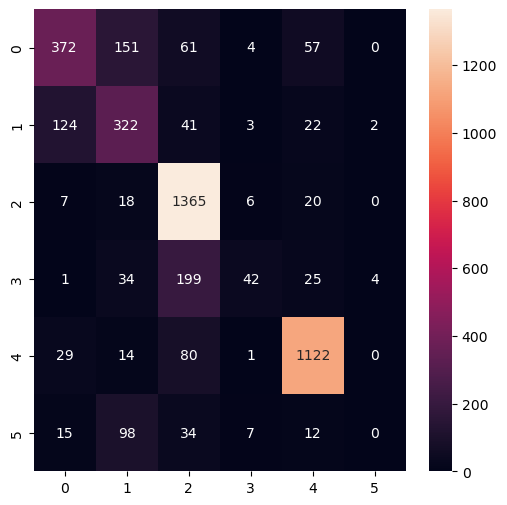

In [40]:
plt.figure(figsize = (6,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = 'd')
plt.show()

### Classification report

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.58      0.62       645
           1       0.51      0.63      0.56       514
           2       0.77      0.96      0.85      1416
           3       0.67      0.14      0.23       305
           4       0.89      0.90      0.90      1246
           5       0.00      0.00      0.00       166

    accuracy                           0.75      4292
   macro avg       0.58      0.53      0.53      4292
weighted avg       0.72      0.75      0.72      4292



### Function that inputs text and outputs the prediction

In [42]:
label = encoder.classes_

In [43]:
def prediction(text):
    sequence = text_encoding([text]) #this does padding and convert to numerical format
    pred = model.predict([sequence])
    pred = np.argmax(pred)
    pred = label[pred]
    return pred

In [50]:
prediction('Hey , i am so happy to meet you')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


np.str_('happy')

***